Found 1820 files belonging to 26 classes.
Found 390 files belonging to 26 classes.
Found 390 files belonging to 26 classes.
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 975s 14s/step - accuracy: 0.0846 - loss: 3.7500 - val_accuracy: 0.1385 - val_loss: 3.0170 - learning_rate: 1.0000e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 691s 12s/step - accuracy: 0.2275 - loss: 2.7761 - val_accuracy: 0.2769 - val_loss: 2.6528 - learning_rate: 1.0000e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 645s 11s/step - accuracy: 0.3505 - loss: 2.3184 - val_accuracy: 0.3154 - val_loss: 2.4030 - learning_rate: 1.0000e-04
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 662s 12s/step - accuracy: 0.4253 - loss: 1.9824 - val_accuracy: 0.3795 - val_loss: 2.2297 - learning_rate: 1.0000e-04
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 676s 12s/step - accuracy: 0.5275 - loss: 1.6473 - val_accuracy: 0.3872 - val_loss: 2.1285 - learning_rate: 1.0000e-04
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 620s 11s/step - accuracy: 0.5819 - loss: 1.4431 - val_accu

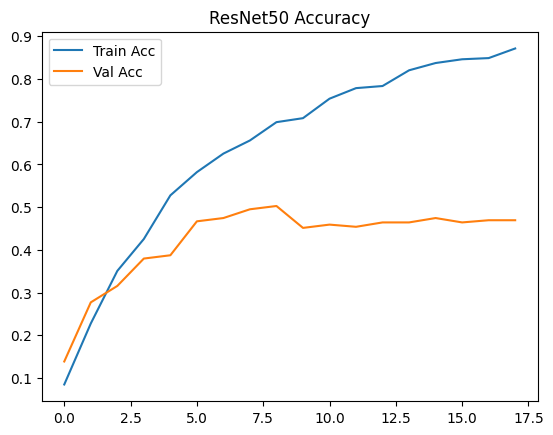

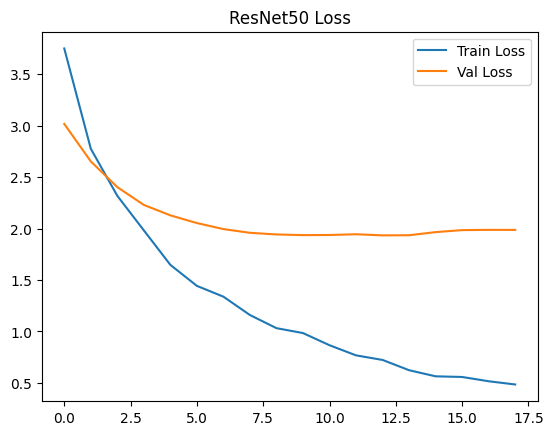

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# =========================
# 1. DATASET LOAD (IMPORTANT FIX)
# =========================
data_dir = r"D:\SmartVision\DataSets\smartvision_dataset\classification"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"   # 🔥 IMPORTANT
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

# =========================
# 2. DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
])

# APPLY ONLY ON TRAIN
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# =========================
# 3. PREPROCESSING (CRITICAL)
# =========================
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

# =========================
# 4. PERFORMANCE OPTIMIZATION
# =========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# =========================
# 5. BASE MODEL
# =========================
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# FREEZE
base_model.trainable = False

# =========================
# 6. CUSTOM HEAD (IMPROVED)
# =========================
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# =========================
# 7. COMPILE
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 8. CALLBACKS (IMPORTANT)
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    )
]

# =========================
# 9. TRAIN (PHASE 1)
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# =========================
# 10. FINE-TUNING (CRITICAL FIX)
# =========================
base_model.trainable = True

# Freeze MOST layers, unfreeze TOP ONLY
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 🔥 LOWER LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 11. TRAIN AGAIN
# =========================
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# =========================
# 12. EVALUATE
# =========================
test_loss, test_acc = model.evaluate(test_ds)

print("🔥 Final Test Accuracy:", test_acc)


# =========================
# 13. Plot
# =========================
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('ResNet50 Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('ResNet50 Loss')
plt.show()